In [1]:
# import libraries
import pandas as pd
import numpy as np
import math
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
import IPython
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import *

#for ignoring warning 
from warnings import filterwarnings
filterwarnings("ignore")

The datasets is from Kaggle dataset repository (https://www.kaggle.com/datasets/bobaaayoung/trafficvolumedatacsv)

In [2]:
# Read dataset
df = pd.read_csv("TrafficVolumeData.csv",parse_dates=['date_time'], index_col=0)
df.head()

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2012-10-02 09:00:00,NaN,121,89,2,329,1,1,288.28,0.0,0.0,40,Clouds,scattered clouds,5545
2012-10-02 10:00:00,NaN,178,67,3,330,1,1,289.36,0.0,0.0,75,Clouds,broken clouds,4516
2012-10-02 11:00:00,NaN,113,66,3,329,2,2,289.58,0.0,0.0,90,Clouds,overcast clouds,4767
2012-10-02 12:00:00,NaN,20,66,3,329,5,5,290.13,0.0,0.0,90,Clouds,overcast clouds,5026
2012-10-02 13:00:00,NaN,281,65,3,329,7,7,291.14,0.0,0.0,75,Clouds,broken clouds,4918


In [3]:
# understanding dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33750 entries, 2012-10-02 09:00:00 to 2017-05-17 23:00:00
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   is_holiday           43 non-null     object 
 1   air_pollution_index  33750 non-null  int64  
 2   humidity             33750 non-null  int64  
 3   wind_speed           33750 non-null  int64  
 4   wind_direction       33750 non-null  int64  
 5   visibility_in_miles  33750 non-null  int64  
 6   dew_point            33750 non-null  int64  
 7   temperature          33750 non-null  float64
 8   rain_p_h             33750 non-null  float64
 9   snow_p_h             33750 non-null  float64
 10  clouds_all           33750 non-null  int64  
 11  weather_type         33750 non-null  object 
 12  weather_description  33750 non-null  object 
 13  traffic_volume       33750 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 3.

There are 33750 entries and 14 features:

0. is_holiday: Indicator if the day is a holiday (none or name of holiday)
1. air_pollution_index: Air quality index value (Integer)
2. humidity: Ambient humidity percentage (Integer)
3. wind_speed: Wind speed at the time of measurement (Integer)
4. wind_direction: Wind direction in degrees (Integer)
5. visibility_in_miles: Visibility range in miles (Integer)
6. dew_point: Dew point temperature (Integer)
7. temperature: Ambient temperature in Kelvin (Float)
8. rain_p_h: Rainfall in mm per hour (Float)
9. snow_p_h: Snowfall in mm per hour (Float)
10. clouds_all: Cloud coverage percentage (Integer)
11. weather_type: General type of weather (e.g., Clear, Rain) (Object)
12. weather_description: Detailed weather description (Object)
13. traffic_volume: Traffic volume count (Integer)
                                               
We find hourly predictions, and data will be captured at 1 hour intervals

## Handle null values

In [4]:
# checking null values and its percentage in every column
df.isnull().sum()

is_holiday             33707
air_pollution_index        0
humidity                   0
wind_speed                 0
wind_direction             0
visibility_in_miles        0
dew_point                  0
temperature                0
rain_p_h                   0
snow_p_h                   0
clouds_all                 0
weather_type               0
weather_description        0
traffic_volume             0
dtype: int64

- most of the null values in is_holiday is for those days where there is no holiday. replace it with "None

In [5]:
df['is_holiday'] = df['is_holiday'].fillna('None')

## Univariate Analysis

#### For numerical columns

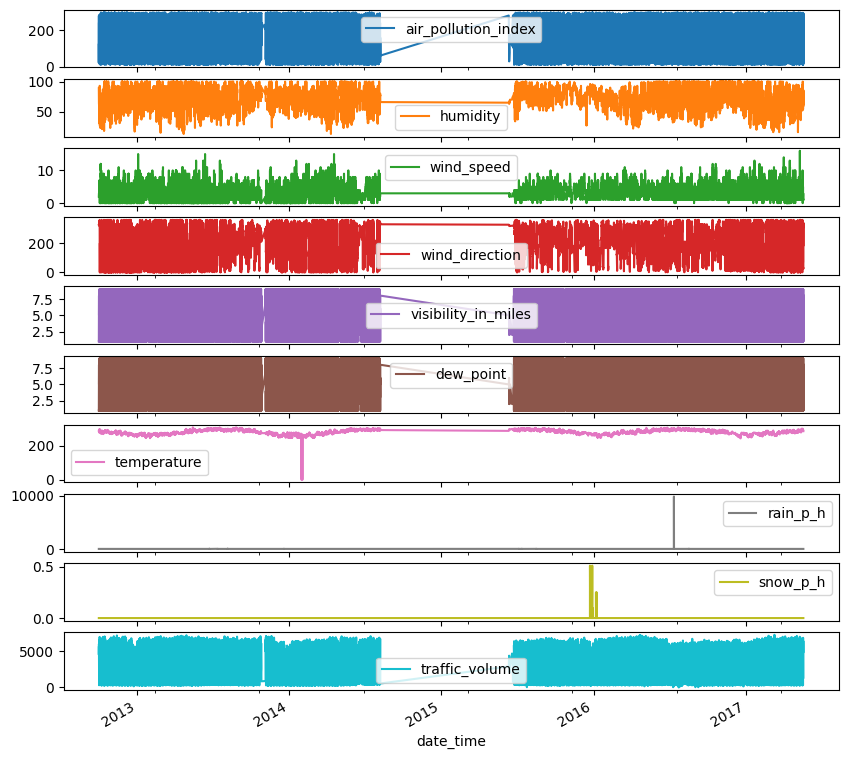

In [6]:
# Analysing the numerical column with respect to date
cols = ['air_pollution_index', 'humidity', 'wind_speed', 'wind_direction','visibility_in_miles', 'dew_point', 'temperature','rain_p_h', 'snow_p_h', 'traffic_volume']
plot_features = df[cols]
_=plot_features.plot(subplots=True, figsize=(10,10))

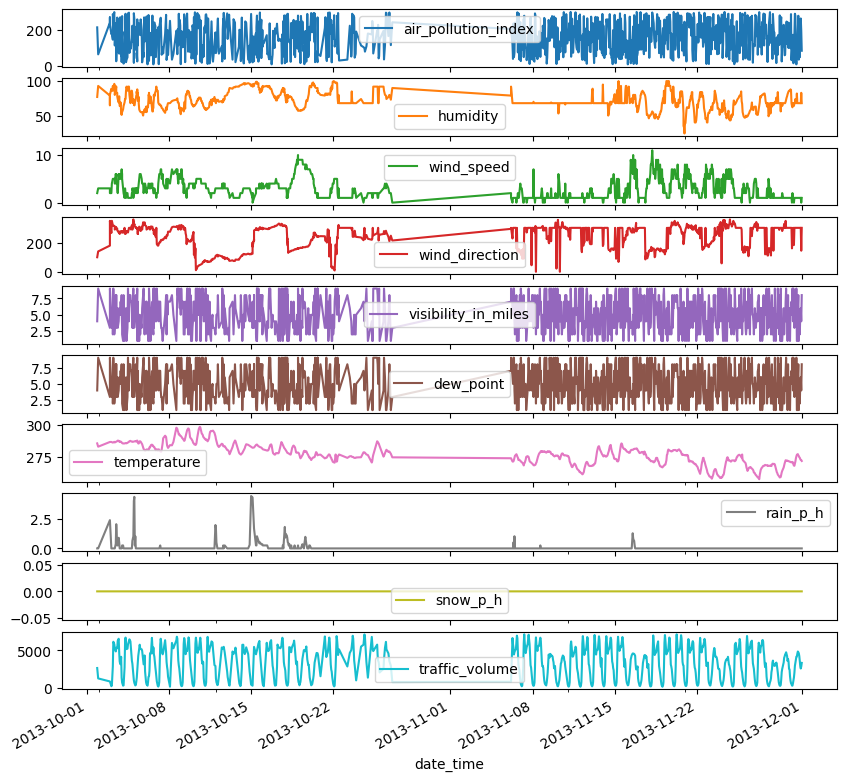

In [7]:
# checking gap for 2013-10 - 2013-11
_ = plot_features['2013-10':'2013-11'].plot(subplots=True, figsize=(10,10))

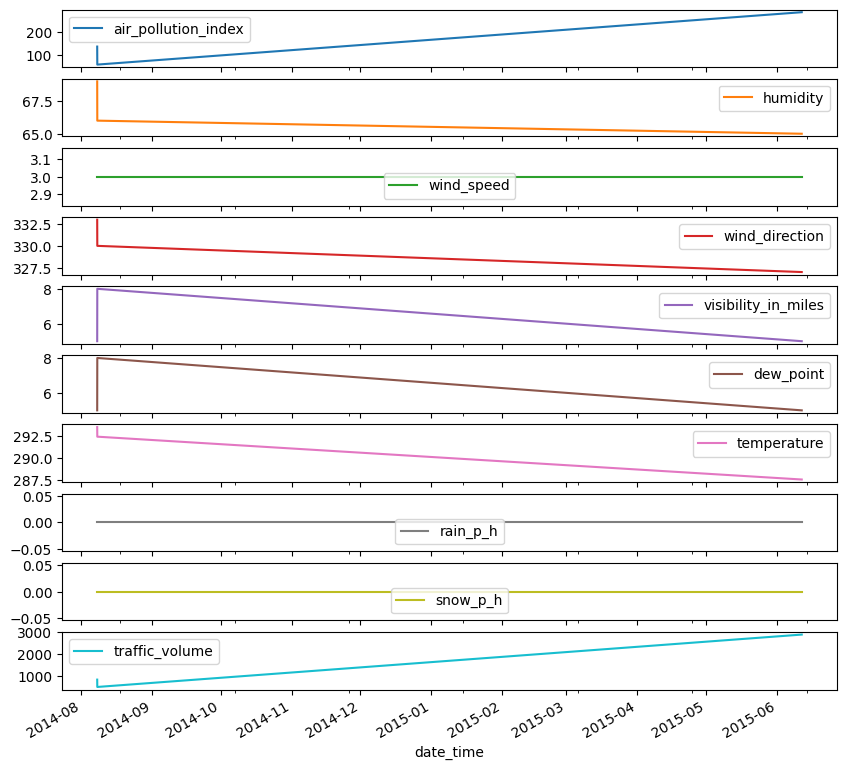

In [8]:
# checking gap for 2014-08 - 015-06
_ = plot_features['2014-08-08':'2015-06-11'].plot(subplots=True, figsize=(10,10))

- There is missing data record between 2013-10 to 2013-11, between 2014-08-08 and 2015-06-11

#### For categorical columns

<Axes: xlabel='count', ylabel='is_holiday'>

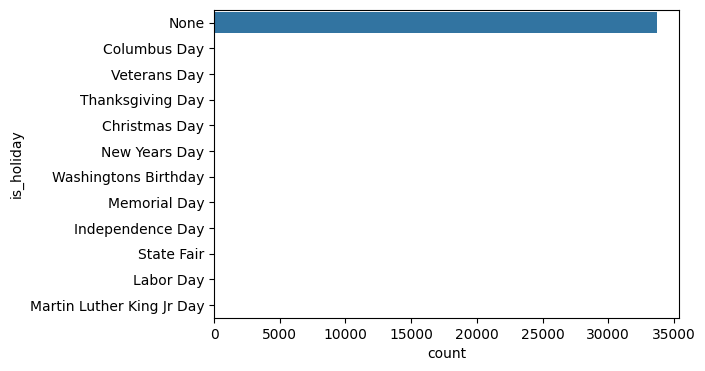

In [9]:
# Plotting frequency of each category in holiday column
plt.figure(figsize = (6,4))
sns.countplot(y='is_holiday', data = df)

- 'None' is far greater than other holidays since most of the days are non-holiday days, let's see the trend without 'None'

<Axes: xlabel='count', ylabel='is_holiday'>

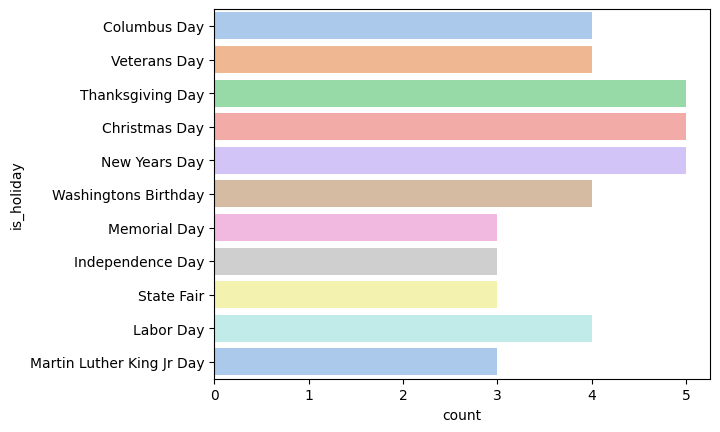

In [10]:
# Plotting frequency of each category in holiday column without none
holidays = df[df['is_holiday'] != 'None']
sns.countplot(y='is_holiday', palette='pastel', data=holidays)

- 99.9% of the holiday data is labeled as 'None,' while the remaining entries are distributed across various holidays.

<Axes: xlabel='count', ylabel='weather_type'>

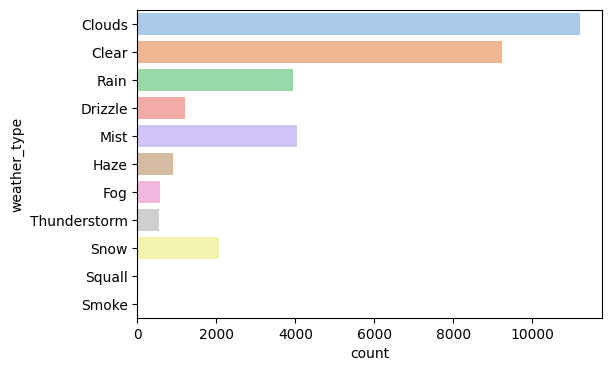

In [11]:
# Plotting frequency of each category in weather_type column
plt.figure(figsize = (6,4))
sns.countplot(y='weather_type', palette='pastel', data = df)

<Axes: xlabel='count', ylabel='weather_description'>

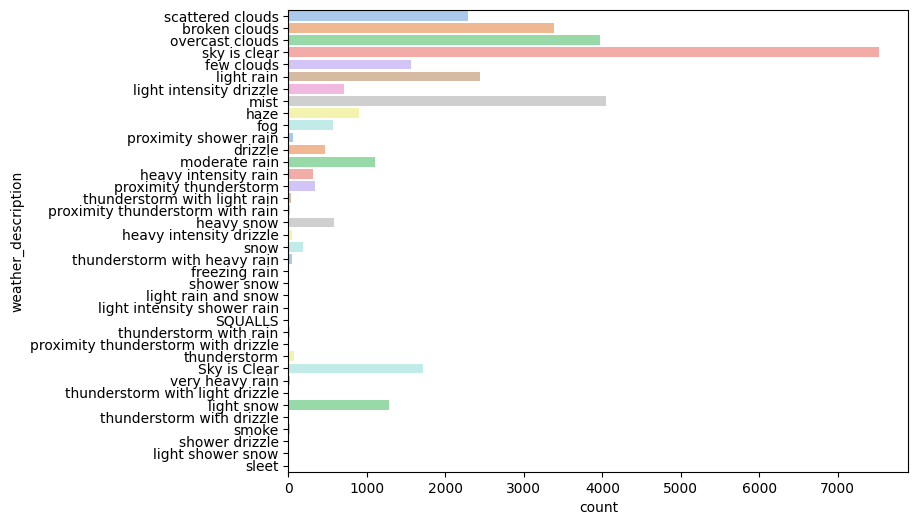

In [12]:
# Plotting frequency of each category in weather_description column
plt.figure(figsize = (8,6))
sns.countplot(y='weather_description', palette='pastel', data = df)

## Handle outliers

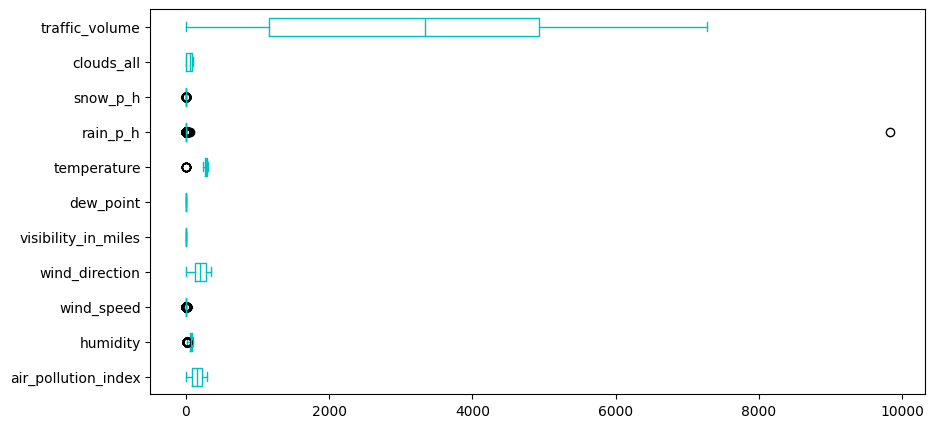

In [13]:
# plotting box plot
df.plot(kind='box',figsize=(10,5),color="c",vert=False)
plt.show()

Observation from above box plot:
  - Some temperature records show values at absolute zero(0 Kelvin), indicating clearly inconsistent data.
  - rain_1h,snow_1h mostly have zero values, but occasionally show very high amounts, making their patterns unclear
  - Visibility is highly consistent
  - Outliers in variables like wind speed, snow, and air pollution index might indicate rare or extreme environmental conditions.

#### Temperature

In [14]:
# checking for days when we have absolute zero
df[df['temperature'] == 0]

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2014-01-31 03:00:00,None,26,78,2,320,1,1,0.0,0.0,0.0,0,Clear,sky is clear,361
2014-01-31 04:00:00,None,18,77,3,310,1,1,0.0,0.0,0.0,0,Clear,sky is clear,734
2014-01-31 05:00:00,None,189,84,3,310,1,1,0.0,0.0,0.0,0,Clear,sky is clear,2557
2014-01-31 06:00:00,None,12,84,4,320,1,1,0.0,0.0,0.0,0,Clear,sky is clear,5150
2014-02-02 03:00:00,None,250,70,0,0,1,1,0.0,0.0,0.0,0,Clear,sky is clear,291
2014-02-02 04:00:00,None,154,76,0,0,3,3,0.0,0.0,0.0,0,Clear,sky is clear,284
2014-02-02 05:00:00,None,151,83,2,220,2,2,0.0,0.0,0.0,0,Clear,sky is clear,434
2014-02-02 06:00:00,None,174,83,0,0,2,2,0.0,0.0,0.0,0,Clear,sky is clear,739
2014-02-02 07:00:00,None,143,83,1,210,9,9,0.0,0.0,0.0,0,Clear,sky is clear,962


-  We see 2 days are having absolute zero temperature [2014-01-31, 2014-02-02]. 

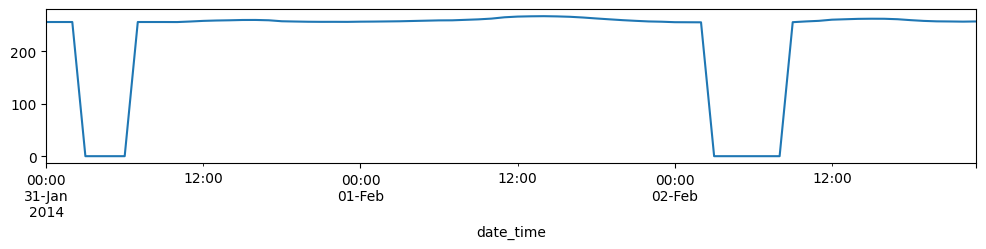

In [15]:
# checking temperature for [2014-01-31 - 2014-02-02]
_ = df['temperature']['2014-01-31':'2014-02-02'].plot(figsize=(12,2))

In [16]:
 df.loc['2014-01-31']

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2014-01-31 00:00:00,None,208,85,3,290,3,3,255.93,0.00,0.0,0,Clear,sky is clear,644
2014-01-31 01:00:00,None,115,78,2,290,3,3,255.93,0.00,0.0,0,Clear,sky is clear,390
2014-01-31 02:00:00,None,61,78,2,290,6,6,255.93,0.00,0.0,0,Clear,sky is clear,313
2014-01-31 03:00:00,None,26,78,2,320,1,1,0.00,0.00,0.0,0,Clear,sky is clear,361
2014-01-31 04:00:00,None,18,77,3,310,1,1,0.00,0.00,0.0,0,Clear,sky is clear,734
2014-01-31 05:00:00,None,189,84,3,310,1,1,0.00,0.00,0.0,0,Clear,sky is clear,2557
2014-01-31 06:00:00,None,12,84,4,320,1,1,0.00,0.00,0.0,0,Clear,sky is clear,5150
2014-01-31 07:00:00,None,287,77,4,320,1,1,255.93,0.00,0.0,0,Clear,sky is clear,5363
2014-01-31 08:00:00,None,191,70,4,320,8,8,255.93,0.00,0.0,0,Clear,sky is clear,5269


- for 2014-01-31, absolute zero from 03:00:00 to 06:00:00 am

In [17]:
 df.loc['2014-02-02']

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2014-02-02 00:00:00,None,221,64,2,260,9,9,255.59,0.0,0.0,0,Clear,sky is clear,1143
2014-02-02 01:00:00,None,203,70,1,260,2,2,255.48,0.0,0.0,0,Clear,sky is clear,695
2014-02-02 02:00:00,None,30,70,0,0,2,2,255.37,0.0,0.0,0,Clear,sky is clear,539
2014-02-02 03:00:00,None,250,70,0,0,1,1,0.00,0.0,0.0,0,Clear,sky is clear,291
2014-02-02 04:00:00,None,154,76,0,0,3,3,0.00,0.0,0.0,0,Clear,sky is clear,284
2014-02-02 05:00:00,None,151,83,2,220,2,2,0.00,0.0,0.0,0,Clear,sky is clear,434
2014-02-02 06:00:00,None,174,83,0,0,2,2,0.00,0.0,0.0,0,Clear,sky is clear,739
2014-02-02 07:00:00,None,143,83,1,210,9,9,0.00,0.0,0.0,0,Clear,sky is clear,962
2014-02-02 08:00:00,None,187,83,0,0,6,6,0.00,0.0,0.0,0,Clear,sky is clear,1670


- for 2014-02-02, absolute zero from 03:00:00 to 08:00:00 am
- We will replace the absolute zero temperature of each day with mean of temp of each day

In [18]:
day_1 = df.index.date == datetime.date(2014, 1, 31)
day_2 = df.index.date == datetime.date(2014, 2, 2)
bad_temps = df['temperature'] == 0

df_1 = df.copy()
# Set the zeros to NaN to be excluded from the mean
df_1.loc[bad_temps,'temperature'] = np.nan 
df_1[bad_temps]

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2014-01-31 03:00:00,None,26,78,2,320,1,1,NaN,0.0,0.0,0,Clear,sky is clear,361
2014-01-31 04:00:00,None,18,77,3,310,1,1,NaN,0.0,0.0,0,Clear,sky is clear,734
2014-01-31 05:00:00,None,189,84,3,310,1,1,NaN,0.0,0.0,0,Clear,sky is clear,2557
2014-01-31 06:00:00,None,12,84,4,320,1,1,NaN,0.0,0.0,0,Clear,sky is clear,5150
2014-02-02 03:00:00,None,250,70,0,0,1,1,NaN,0.0,0.0,0,Clear,sky is clear,291
2014-02-02 04:00:00,None,154,76,0,0,3,3,NaN,0.0,0.0,0,Clear,sky is clear,284
2014-02-02 05:00:00,None,151,83,2,220,2,2,NaN,0.0,0.0,0,Clear,sky is clear,434
2014-02-02 06:00:00,None,174,83,0,0,2,2,NaN,0.0,0.0,0,Clear,sky is clear,739
2014-02-02 07:00:00,None,143,83,1,210,9,9,NaN,0.0,0.0,0,Clear,sky is clear,962


In [19]:

# The means to be used for each day
print(df_1[day_1].temperature.mean())
print(df_1[day_2].temperature.mean())

257.14
258.4327777777778


In [20]:
# Set day 1 values
df_1.loc[bad_temps & day_1, 'temperature'] = df_1[day_1].temperature.mean()
df_1.loc[bad_temps & day_1]

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2014-01-31 03:00:00,None,26,78,2,320,1,1,257.14,0.0,0.0,0,Clear,sky is clear,361
2014-01-31 04:00:00,None,18,77,3,310,1,1,257.14,0.0,0.0,0,Clear,sky is clear,734
2014-01-31 05:00:00,None,189,84,3,310,1,1,257.14,0.0,0.0,0,Clear,sky is clear,2557
2014-01-31 06:00:00,None,12,84,4,320,1,1,257.14,0.0,0.0,0,Clear,sky is clear,5150


In [21]:
# Set day 2 values
df_1.loc[bad_temps & day_2, 'temperature'] = df_1[day_2].temperature.mean()
df_1.loc[bad_temps & day_2]

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2014-02-02 03:00:00,None,250,70,0,0,1,1,258.432778,0.0,0.0,0,Clear,sky is clear,291
2014-02-02 04:00:00,None,154,76,0,0,3,3,258.432778,0.0,0.0,0,Clear,sky is clear,284
2014-02-02 05:00:00,None,151,83,2,220,2,2,258.432778,0.0,0.0,0,Clear,sky is clear,434
2014-02-02 06:00:00,None,174,83,0,0,2,2,258.432778,0.0,0.0,0,Clear,sky is clear,739
2014-02-02 07:00:00,None,143,83,1,210,9,9,258.432778,0.0,0.0,0,Clear,sky is clear,962
2014-02-02 08:00:00,None,187,83,0,0,6,6,258.432778,0.0,0.0,0,Clear,sky is clear,1670


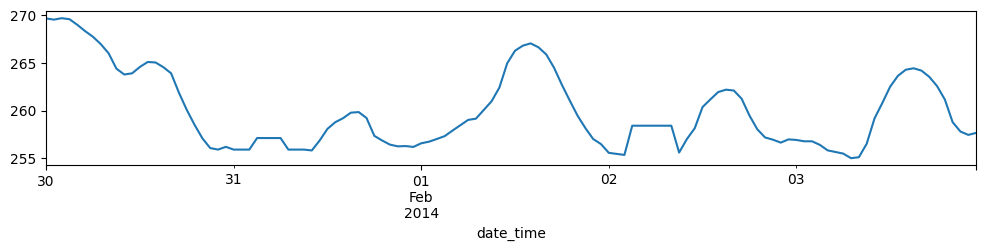

In [22]:
# Plotting to check
plot_features = df_1['temperature']['2014-01-30':'2014-02-03']
_ = plot_features.plot(figsize=(12,2))

#### Rain, Snow, air_pollution_index, wind_speed, wind_direction and dew_point

- It looks like rain has only one record with an extreme value; replace it with the overall mean value for rain.

In [23]:
df_1[df_1.rain_p_h > 100]

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2016-07-11 17:00:00,None,163,33,4,240,1,1,302.11,9831.3,0.0,75,Rain,very heavy rain,5535


In [24]:
# replace it with mean
df_2 = df_1.copy()
df_2.loc['2016-07-11 17:00:00','rain_p_h'] = np.nan
df_2.loc['2016-07-11 17:00:00','rain_p_h'] = df_2.rain_p_h.mean()

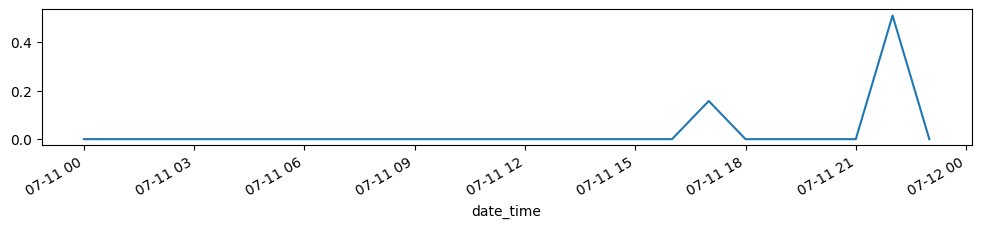

In [25]:
plot_features = df_2.loc['2016-07-11'].rain_p_h
_ = plot_features.plot(figsize=(12,2))

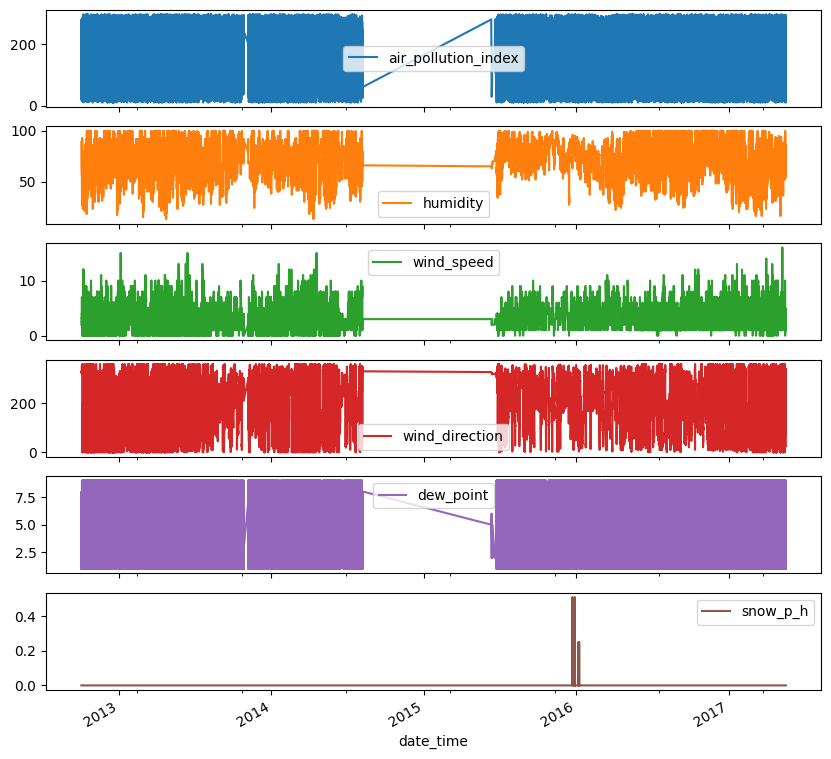

In [26]:
cols = ['air_pollution_index', 'humidity', 'wind_speed', 'wind_direction', 'dew_point', 'snow_p_h']
plot_features = df[cols]
_=plot_features.plot(subplots=True, figsize=(10,10))

- Outliers in these features are no that extreme value and in some condition might indicate rare or extreme environmental conditions. We will keep it as it is

## Feature Engineering

In [27]:
df_2.head(5)

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2012-10-02 09:00:00,None,121,89,2,329,1,1,288.28,0.0,0.0,40,Clouds,scattered clouds,5545
2012-10-02 10:00:00,None,178,67,3,330,1,1,289.36,0.0,0.0,75,Clouds,broken clouds,4516
2012-10-02 11:00:00,None,113,66,3,329,2,2,289.58,0.0,0.0,90,Clouds,overcast clouds,4767
2012-10-02 12:00:00,None,20,66,3,329,5,5,290.13,0.0,0.0,90,Clouds,overcast clouds,5026
2012-10-02 13:00:00,None,281,65,3,329,7,7,291.14,0.0,0.0,75,Clouds,broken clouds,4918


#### Holidays and Weekends

The key information to capture is whether the day is a holiday or a weekend. We don’t need to distinguish specific holidays, so we’ll create Indicator if the day is a holiday (1 for holiday, 0 otherwise). Similarly, we don’t need to differentiate between weekends, so we’ll create a new feature, is_weekend

In [28]:
# Holidays (1 for holiday, 0 otherwise)
df_3 = df_2.copy()
df_3['is_holiday'] = (df_3['is_holiday'] != 'None').astype(int)
df_3['is_holiday'].unique()

array([0, 1])

In [29]:
# weekend (1 for weekend, 0 weekdays)
df_3['is_weekend'] = df_3.index.day_name().isin(['Saturday', 'Sunday']).astype(int)

In [30]:
# check for weekend 
df_3[df_3['is_weekend'] == 1].index.day_name()

Index(['Saturday', 'Saturday', 'Saturday', 'Saturday', 'Saturday', 'Saturday',
       'Saturday', 'Saturday', 'Saturday', 'Saturday',
       ...
       'Sunday', 'Sunday', 'Sunday', 'Sunday', 'Sunday', 'Sunday', 'Sunday',
       'Sunday', 'Sunday', 'Sunday'],
      dtype='object', name='date_time', length=9558)

#### weather_type and Weather description

do one-hot encode on weather_type and drop weather_description since it provides redundant information that overlaps with weather_main

In [31]:
# dropping weather_description column
df_4 = df_3.copy()
df_4 = df_4.drop(['weather_description'], axis=1)

# one-hot encoding weather_type column
df_4 = pd.get_dummies(df_4, columns=['weather_type'], prefix='weather')
df_4.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33750 entries, 2012-10-02 09:00:00 to 2017-05-17 23:00:00
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   is_holiday            33750 non-null  int32  
 1   air_pollution_index   33750 non-null  int64  
 2   humidity              33750 non-null  int64  
 3   wind_speed            33750 non-null  int64  
 4   wind_direction        33750 non-null  int64  
 5   visibility_in_miles   33750 non-null  int64  
 6   dew_point             33750 non-null  int64  
 7   temperature           33750 non-null  float64
 8   rain_p_h              33750 non-null  float64
 9   snow_p_h              33750 non-null  float64
 10  clouds_all            33750 non-null  int64  
 11  traffic_volume        33750 non-null  int64  
 12  is_weekend            33750 non-null  int32  
 13  weather_Clear         33750 non-null  bool   
 14  weather_Clouds        33750 non-nul

#### Time

In [32]:
# Converts the datetime index into Unix timestamps
timestamp_s = df_4.index.map(datetime.datetime.timestamp)

- A day is represented in seconds as 24×60×60=86400. A year is approximately 365.2425×86400=31,556,952 seconds (accounting for leap years).
- Traffic flow follows seasonal and periodic patterns influenced by daily and yearly cycles.

##### Time is Cyclical
Time-based features like "Time of day" or "Time of year" repeat in a circular pattern:
 - The hours reset after 24 (e.g., 23:59 transitions to 00:00).
 - The months reset after 12 (e.g., December transitions to January).
Using numerical representations alone (e.g., 23 for 11 PM and 0 for midnight) introduces discontinuities that traditional machine learning models struggle to handle

Sine and cosine are smooth, continuous functions that represent cycles perfectly.
 - They repeat this pattern for every cycle.
 - This encoding ensures there are no sharp jumps or discontinuities when the cycle restarts.

In [33]:
# time period
day = 24 * 60 * 60
year = 365.2425 * day

# Creating Daily Cycles
df_4['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df_4['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))

# Creating Yearly Cycles
df_4['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df_4['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

df_4.head(5)

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,...,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm,Day sin,Day cos,Year sin,Year cos
date_time,,,,,,,,,,,,,,,,,,,,,
2012-10-02 09:00:00,0,121,89,2,329,1,1,288.28,0.0,0.0,...,False,False,False,False,False,False,0.793353,0.608761,-0.999843,0.017700
2012-10-02 10:00:00,0,178,67,3,330,1,1,289.36,0.0,0.0,...,False,False,False,False,False,False,0.923880,0.382683,-0.999830,0.018417
2012-10-02 11:00:00,0,113,66,3,329,2,2,289.58,0.0,0.0,...,False,False,False,False,False,False,0.991445,0.130526,-0.999817,0.019133
2012-10-02 12:00:00,0,20,66,3,329,5,5,290.13,0.0,0.0,...,False,False,False,False,False,False,0.991445,-0.130526,-0.999803,0.019850
2012-10-02 13:00:00,0,281,65,3,329,7,7,291.14,0.0,0.0,...,False,False,False,False,False,False,0.923880,-0.382683,-0.999788,0.020567


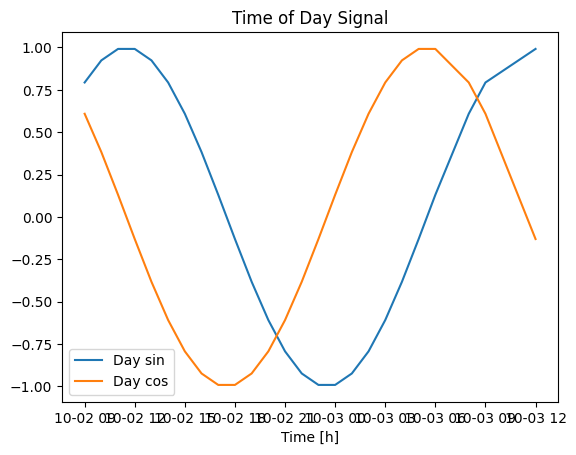

In [34]:
# plotting day sin and cos
plt.plot(df_4[['Day sin', 'Day cos']].iloc[:25])
plt.xlabel('Time [h]')
plt.title('Time of Day Signal')
plt.legend(['Day sin', 'Day cos'])

In [35]:
# creating date related column from data
df_4['dayofweek'] = df_4.index.dayofweek
df_4['day'] = df_4.index.day
df_4['month'] = df_4.index.month
df_4['year'] = df_4.index.year
df_4['day_hour'] = df_4.index.hour

In [36]:
df_4

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,...,weather_Thunderstorm,Day sin,Day cos,Year sin,Year cos,dayofweek,day,month,year,day_hour
date_time,,,,,,,,,,,,,,,,,,,,,
2012-10-02 09:00:00,0,121,89,2,329,1,1,288.28,0.0,0.0,...,False,0.793353,0.608761,-0.999843,0.017700,1,2,10,2012,9
2012-10-02 10:00:00,0,178,67,3,330,1,1,289.36,0.0,0.0,...,False,0.923880,0.382683,-0.999830,0.018417,1,2,10,2012,10
2012-10-02 11:00:00,0,113,66,3,329,2,2,289.58,0.0,0.0,...,False,0.991445,0.130526,-0.999817,0.019133,1,2,10,2012,11
2012-10-02 12:00:00,0,20,66,3,329,5,5,290.13,0.0,0.0,...,False,0.991445,-0.130526,-0.999803,0.019850,1,2,10,2012,12
2012-10-02 13:00:00,0,281,65,3,329,7,7,291.14,0.0,0.0,...,False,0.923880,-0.382683,-0.999788,0.020567,1,2,10,2012,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-05-17 21:00:00,0,74,85,1,328,7,7,287.88,0.0,0.0,...,False,-0.793353,-0.608761,0.703663,-0.710534,2,17,5,2017,21
2017-05-17 22:00:00,0,81,70,1,24,2,2,286.95,0.0,0.0,...,False,-0.923880,-0.382683,0.703154,-0.711038,2,17,5,2017,22
2017-05-17 22:00:00,0,138,70,1,24,1,1,286.95,0.0,0.0,...,False,-0.923880,-0.382683,0.703154,-0.711038,2,17,5,2017,22


In [37]:
# Rearrange the columns so that traffic_volume is the first column, making it more convenient for use during predictions later
columns_order = [
    'traffic_volume', 'Day sin', 'Day cos', 'Year sin', 'Year cos',
    'temperature', 'clouds_all', 'rain_p_h', 'snow_p_h','is_weekend', 
    'is_holiday', 'air_pollution_index', 'humidity', 'wind_speed',
    'wind_direction', 'visibility_in_miles', 'dew_point','weather_Clear', 
    'weather_Clouds', 'weather_Drizzle', 'weather_Fog','weather_Haze', 'weather_Mist',
    'weather_Rain', 'weather_Smoke','weather_Snow', 'weather_Squall', 'weather_Thunderstorm',
    'dayofweek', 'day', 'month', 'year','day_hour'
]
df_4 = df_4[columns_order]

In [38]:
# copy the clean data
df_clean = df_4.copy()

## Timeseries data processing

#### Splitting dataset

We will not randomly shuffle data before splitting because :
1. Preserving Sequential Order:
    - Time-series data depends on the chronological order to capture trends and patterns.
    - Random shuffling would disrupt this sequence, making it impossible to predict future values based on past observations (e.g., using the last 24 hours for predictions).Realistic Validation and Testing:

2. In real-world applications, predictions are made on unseen future data.
    - Splitting data chronologically ensures the validation and test sets simulate future data, leading to more realistic evaluation

In [39]:
# splitting df_clean into training, validation, and test subsets based on their indices, without any time-series resampling
train_df0 = df_clean[:-15000]
print("Training:", train_df0.shape[0])
val_df0 = df_clean[-15000:-5000]
print("Validation:", val_df0.shape[0])
test_df0 = df_clean[-5000:]
print("Test:", test_df0.shape[0])

Training: 18750
Validation: 10000
Test: 5000


Earlier we have notices that we have missing data for 2 intervals of time(between 2013-10 to 2013-11 and between 2014-08-08 to 2015-06-11),So with help of resampling the dataset to 1-hour intervals ensures consistency and reliability, even if the original data appears to have 1-hour intervals. This step:
  - Handles Missing or Irregular Intervals: Fills gaps( using .pad()) or fixes irregularities in timestamps.
  - Aggregates Data: Combines duplicate or sub-hour intervals into consistent 1-hour bins (using .mean()).

In [40]:
# splitting again with resampling the dataset to have consistent 1-hour intervals
train_df = df_clean[:-15000].resample('1H').mean().pad()
print("Training:", train_df.shape[0])
val_df= df_clean[-15000:-5000].resample('1H').mean().pad()
print("Validation:", val_df.shape[0])
test_df = df_clean[-5000:].resample('1H').mean().pad()
print("Test:", test_df.shape[0])

Training: 26304
Validation: 10219
Test: 4002


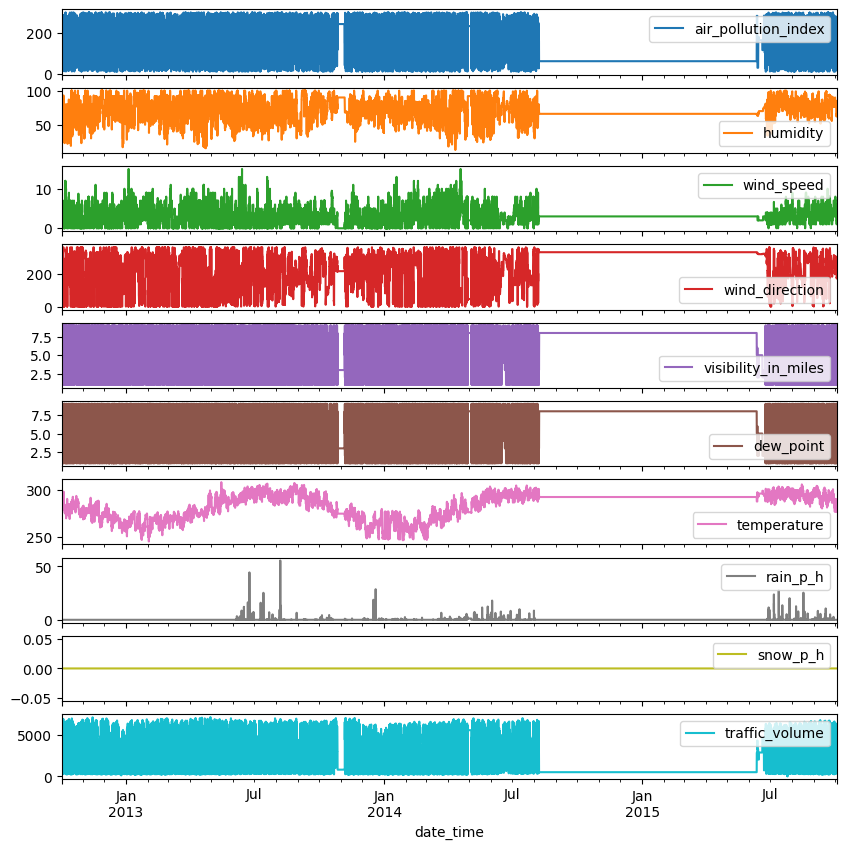

In [41]:
# plotting train dataset
cols = ['air_pollution_index', 'humidity', 'wind_speed', 'wind_direction','visibility_in_miles', 'dew_point', 'temperature','rain_p_h', 'snow_p_h', 'traffic_volume']
_=train_df[cols].plot(subplots=True, figsize=(10,10))

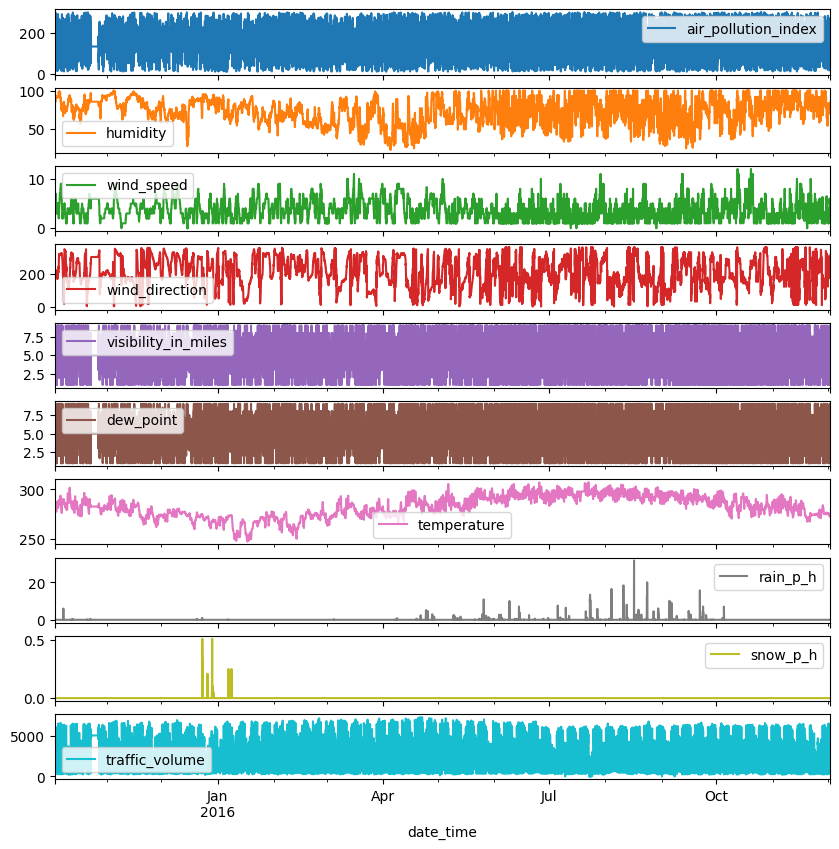

In [42]:
# plotting validation dataset
_=val_df[cols].plot(subplots=True, figsize=(10,10))

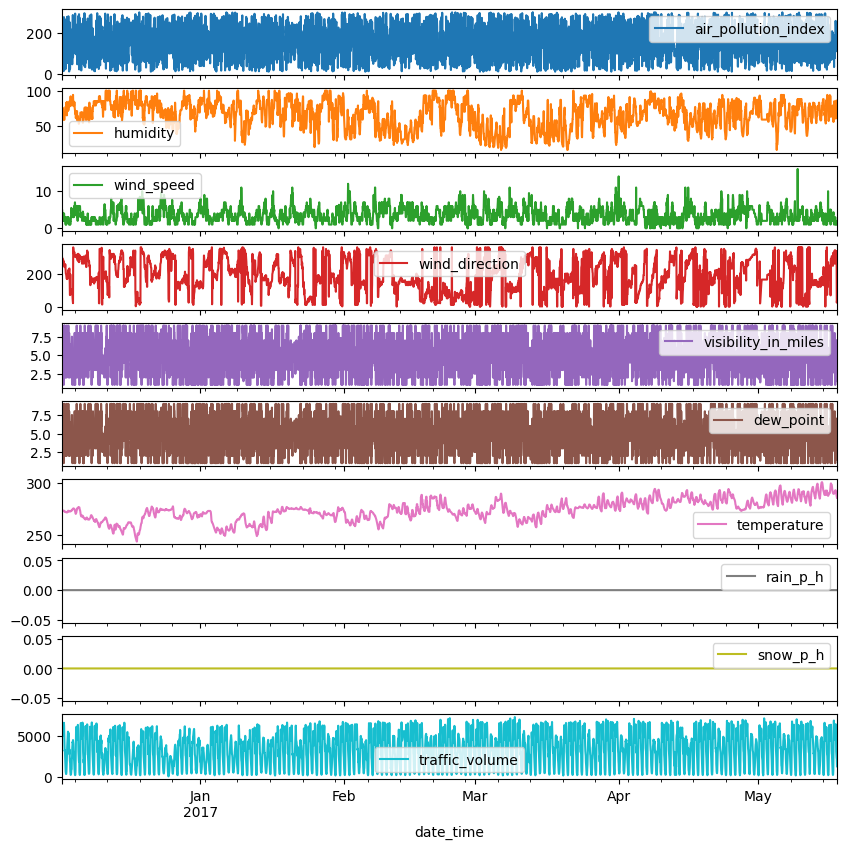

In [43]:
# plotting test dataset
_=test_df[cols].plot(subplots=True, figsize=(10,10))

- Notice that the test data does not include any rain or snow data points. 

#### Normalisation

In [44]:
# We are scaling features using scikit-learn MinMaxScaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler().fit(train_df)
scaler_tv = MinMaxScaler().fit(train_df[['traffic_volume']])
scaled_train_df = pd.DataFrame(scaler.transform(train_df), index=train_df.index, columns=train_df.columns)
scaled_val_df = pd.DataFrame(scaler.transform(val_df), index=val_df.index, columns=val_df.columns)
scaled_test_df = pd.DataFrame(scaler.transform(test_df), index=test_df.index, columns=test_df.columns)


#### WindowGenerator

We wll create WindowGenerator clas for handling time-series data. It manages the creation of training, validation, and test datasets with sliding windows. following key parameters in class:
  1. input_width: Number of time steps in the input window.
  2. label_width: Number of time steps in the output window (labels).
  3. shift: Offset between the last input and the first label.
  4. batch_size: Number of samples per batch.
  5. train_df, val_df, test_df: DataFrames for training, validation, and testing.
  6. label_columns: Specific columns to use as labels.

In [45]:
'''
The WindowGenerator class.
This class can:
1 - Handle the indexes and offsets.
2 - Split windows of features into a (features, labels) pairs.
3 - Plot the content of the resulting windows.
4 - Efficiently generate batches of these windows from the training, evaluation, and test data, using tf.data.Datasets.
'''
class WindowGenerator():
    def __init__(self, input_width, label_width, shift, batch_size, 
                 train_df=scaled_train_df, val_df=scaled_val_df, test_df=None, label_columns=scaled_test_df):
        # Store the raw data
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.example = None

        # Work on label column indices
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}  # { "traffic_vol": 0 }
            
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}  # {"traffic_vol": 0, "Day sin": 1 ...}
        
        # Work on window parameters
        self.input_width = input_width 
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift
        self.batch_size = batch_size
        
        self.input_slice = slice(0, input_width)  # slice(0, 6)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]  # [0, 1, 2, 3, 4, 5]
        
        self.label_start = self.total_window_size - self.label_width  # 10-1=9 
        self.labels_slice = slice(self.label_start, None)  # slice(9,)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]  # [9]
        
    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_indices}',
            f'Label indices: {self.label_indices}',
            f'Label column name(s): {self.label_columns}'
        ])
        
    # Splitting the window into input window and label window
    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns], axis=-1
            )
        
        # Setting shapes manually
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        
        return inputs, labels
    
    # Plotting a simple visualization of split windows
    def plot(self, model=None, plot_col='traffic_volume', max_subplots=3):
        inputs, labels = self.example
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))

        for n in range(max_n):
            # Plotting inputs
            plt.subplot(max_n, 1, n + 1)
            plt.ylabel(f'{plot_col} [normed]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                     label='Inputs', marker='.', zorder=-10)

            # Plotting labels
            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', label='Labels', c='#2ca02c', s=64)

            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions',
                            c='#ff7f0e', s=64)

            if n == 0:
                plt.legend()
        plt.xlabel('Time [h]')
        plt.suptitle(f'Showing {max_n} slices')
    
    # Convert time series DataFrame into tf.data.Dataset of input and label window
    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=False,
            batch_size=self.batch_size,
        )
        ds = ds.map(self.split_window)
        return ds

    '''
       WindowGenerator object holds training, validation, and test data.
       Add properties for accessing them as tf.data.Datasets using the make_dataset method you defined earlier.
       Also, add a standard example batch for easy access and plotting
    '''

    @property
    def train(self):
        return self.make_dataset(self.train_df)
        
    @property
    def test(self):
        return self.make_dataset(self.test_df)
        
    @property
    def val(self):
        return self.make_dataset(self.val_df)
        
    @property
    def example(self):
        ''' Get and cache an example batch of input, labels for plotting.'''
        result = getattr(self, '_example', None)
        if result is None:
            # no example batch was found, so get one from train dataset
            result = next(iter(self.train))
            # and cache it for next time
            self._example = result
        return result
   
    @example.setter
    def example(self, var):
        self._example = var
 

#### Plotting training validation

plot_train_validation use to visualize the training and validation metrics during the model training process and evaluates the model on the validation setParameters:
  - history: A History object returned by the model.fit() method. It contains logs of training metrics for each epoch.
  - validation_data: The validation dataset used to evaluate the model's performance after training.
  - metric: The metric to plot (default is 'mean_absolute_error').

In [46]:
def plot_train_validation(history, validation_data, metric = 'mean_absolute_error'):
    
    plt.plot(history.history[metric], label='train')         # MAE for training after each epoch
    plt.plot(history.history['val_'+metric], label='valid')  # MAE for validation after each epoch
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(f'{len(history.history[metric])} epochs')
    plt.grid(color='lightgrey', linestyle=':', linewidth=0.5)
    plt.legend(loc='upper right')
    plt.show()

    # print evaluated learned model with validation set
    print('\n\n VALIDATION SCORES: \n')
    _ = history.model.evaluate(validation_data, verbose=2)

#### Training Plotting

The TrainingPlot class is a custom Keras callback that visualizes the training and validation metrics after each epoch. 
  - A subclass of tf.keras.callbacks.Callback. It allows custom actions to be executed at different stages of model training
  - loss_metric: Specifies the metric to track and plot (default: mean_absolute_error)
  - self.losses: To store the training loss/metric values.
  - self.val_losses: To store validation loss/metric values.
  - self.logs: To store the logs for each epoch.

In [47]:
class TrainingPlot(Callback):
    '''
    Keras callback helper class to plot training/validation
    plot after each epoch
    '''
    def __init__(self, loss_metric='mean_absolute_error'):
      super().__init__()
      self.loss_metric = loss_metric

    # This function is called when the training begins
    def on_train_begin(self, logs={}):
        # Initialize the lists for holding the logs, losses and metrics
        self.losses = []
        self.val_losses = []
        self.logs = []
    
    # This function is called at the end of each epoch
    def on_epoch_end(self, epoch, logs={}):
        loss = logs.get(self.loss_metric)
        val_loss = logs.get('val_'+self.loss_metric)
        
        # Appending logs, losses and accuracy to the lists
        self.logs.append(logs)
        self.losses.append(loss)
        self.val_losses.append(val_loss)
        
        # Plot every n-th epoch
        if epoch>0 and epoch%1==0:
            # clear pervious plot
            IPython.display.clear_output(wait=True)
            N = np.arange(0, len(self.losses))  # no. of epochs
            
            plt.xlabel('Epoch')
            plt.ylabel(self.loss_metric)
            plt.plot(N, self.losses, label='Train')
            plt.plot(N, self.val_losses, label='Validation')
            plt.grid(color='lightgrey', linestyle=':', linewidth=0.5)
            val_denorm = float(scaler_tv.inverse_transform(np.array([[val_loss]])))
            plt.title(f'Last validation value = {val_denorm:.2f}')
            plt.legend(loc='upper right')          
            plt.show()

#### Compile and fit

following key parameters in class:
  1. model: The TensorFlow/Keras model to be trained.
  2. window: An instance of the WindowGenerator class containing training and validation datasets.
  3. patience: The number of epochs to wait for improvement before stopping training or reducing the learning rate.
  4. max_epochs: The maximum number of epochs for training.
  5. model_label: A string label for the model, used in logging and storing results.
  6. log_dict: A dictionary to store training performance and predictions, allowing results to be logged and retrieved later.

In [93]:
def compile_and_fit(model, window, patience=5, max_epochs=30,
                    model_label='model', log_dict=None):
 
    rlr = ReduceLROnPlateau(monitor='val_loss',factor=0.5, min_delta=0.001, 
                            patience=patience, model='min', verbose=1)
    
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience,
                                                      mode='min',restore_best_weights=True)
    model.compile(optimizer="adam", loss="mean_squared_error",metrics=['mean_absolute_error'])
    history = model.fit(window.train, epochs=max_epochs, validation_data=window.val,
                        callbacks=[TrainingPlot(), early_stopping, rlr])
                            
    if log_dict:
         log_dict['my_models'][model_label]=model
         
         IPython.display.clear_output()
         
         print('TRAINING VS. VALIDATION')
         plot_train_validation(history, window.val)
         
         # update log dict
         log_dict['multi_val_performance'][model_label] = model.evaluate(window.val, verbose=0)
         log_dict['multi_performance'][model_label] = model.evaluate(window.train, verbose=0)
    
    predictions = model.predict(window.val)
    evaluate_predictions(val_df.traffic_volume, predictions)
    return history


#### Evaluate predictions

Evaluate_predictions function evaluates the model's predictions against the true values and visualizes the comparison.
  - y_true: The true (ground truth) values for the target variable.
  - y_pred: The predicted values from the model.
  - plot_start_index: The starting index for slicing data when plotting (defaults to the last 500 data points).

In [88]:
def evaluate_predictions(y_true, y_pred, plot_start_index=-500):
    print('PREDICTIONS EVALUATION:')
    y_p = np.asarray(scaler_tv.inverse_transform(y_pred.reshape(-1,1))).ravel()
    n_predictions = len(y_p)
    y= np.asarray(y_true[-n_predictions:]).ravel()
    print('Predictions:', n_predictions)
    mae = float(tf.metrics.mae(y, y_p))
    mae_scaled = float(scaler_tv.transform(np.array([[mae]])))
    print(f'MAE:{mae:.2f} ({mae_scaled:.4f})')
    
    plt.subplots(figsize=(15,2))
    plt.plot(y[plot_start_index:], marker='.', label='true')
    plt.plot(y_p[plot_start_index:], marker='.', label='predicted')
    plt.legend()
    plt.show()

#### Creating window

Creating winodow that predict single output value which is traffice volumne at 8th day based on input of full feature of 6 days

Total window size: 8
Input indices: [0 1 2 3 4 5]
Label indices: [7]
Label column name(s): ['traffic_volume']

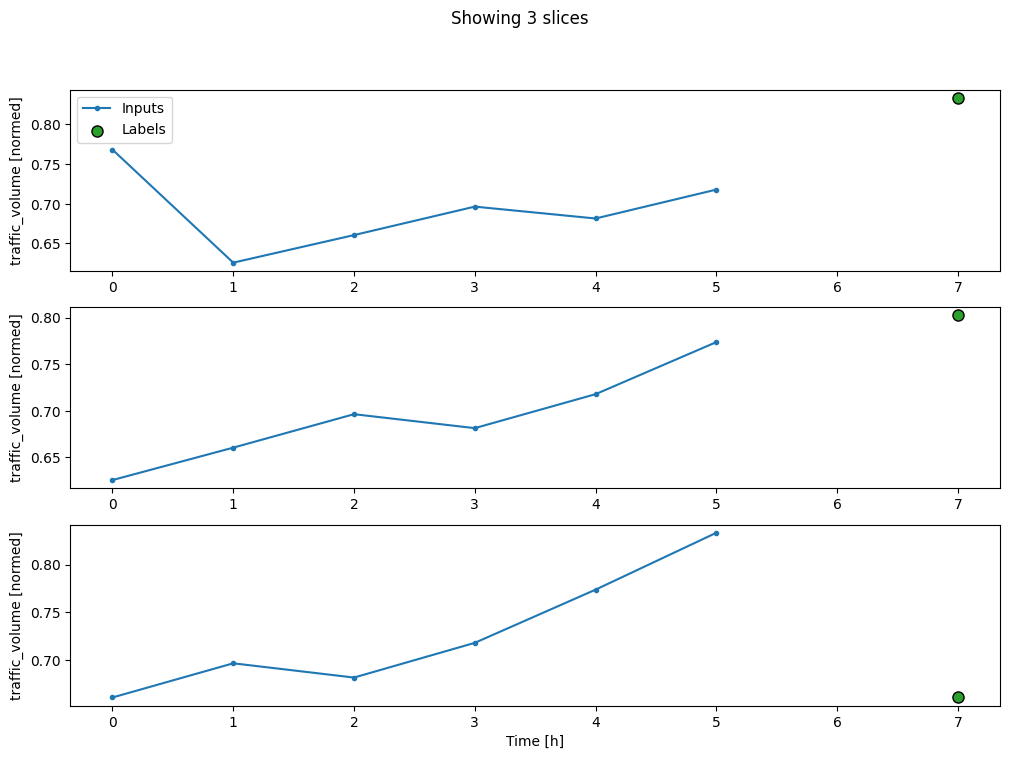

In [89]:
INPUT_WIDTH = 6
OUT_STEPS = 1
SHIFT = 2
base_window = WindowGenerator(input_width=INPUT_WIDTH,
                               label_width=OUT_STEPS,
                               shift=SHIFT, label_columns=['traffic_volume'],
                               batch_size=32
                               )

base_window.plot()
base_window

### Modeling

Before building a trainable model it would be good to have a performance baseline as a point for comparison with the later more complicated models.

In [100]:
multi_val_performance = {}
multi_performance = {}
my_models = {}

my_log = {
    'multi_val_performance':multi_val_performance,
    'multi_performance':multi_performance,
    'my_models':my_models
    }

#### Dense

Let's stacks several a few Dense layers between the input and the output

TRAINING VS. VALIDATION


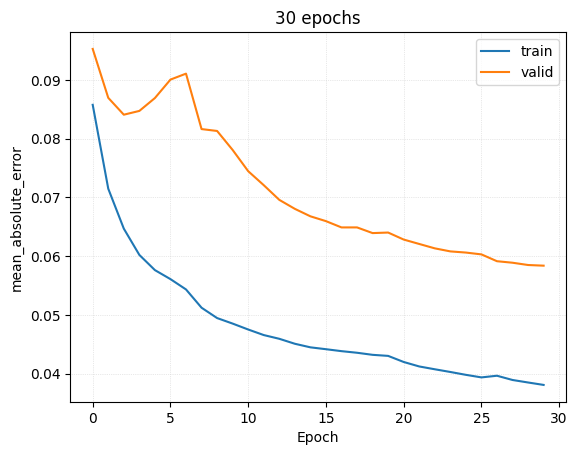



 VALIDATION SCORES: 

320/320 - 1s - 2ms/step - loss: 0.0069 - mean_absolute_error: 0.0584
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
PREDICTIONS EVALUATION:
Predictions: 10212
MAE:421.31 (0.0582)


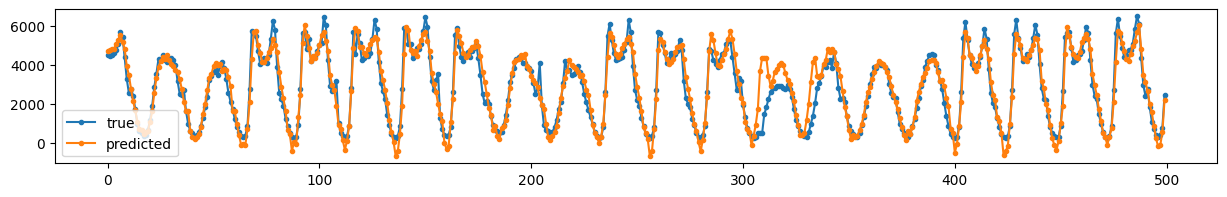

In [101]:
# build dense model
current_window = base_window

dense_model = tf.keras.Sequential([
    Lambda(lambda x: x[:, -1:, :]),
    Dense(512, activation ='relu'),
    Dense(OUT_STEPS)
])

# compile 
history = compile_and_fit(dense_model, current_window, model_label= 'Dense',
                          log_dict=my_log)

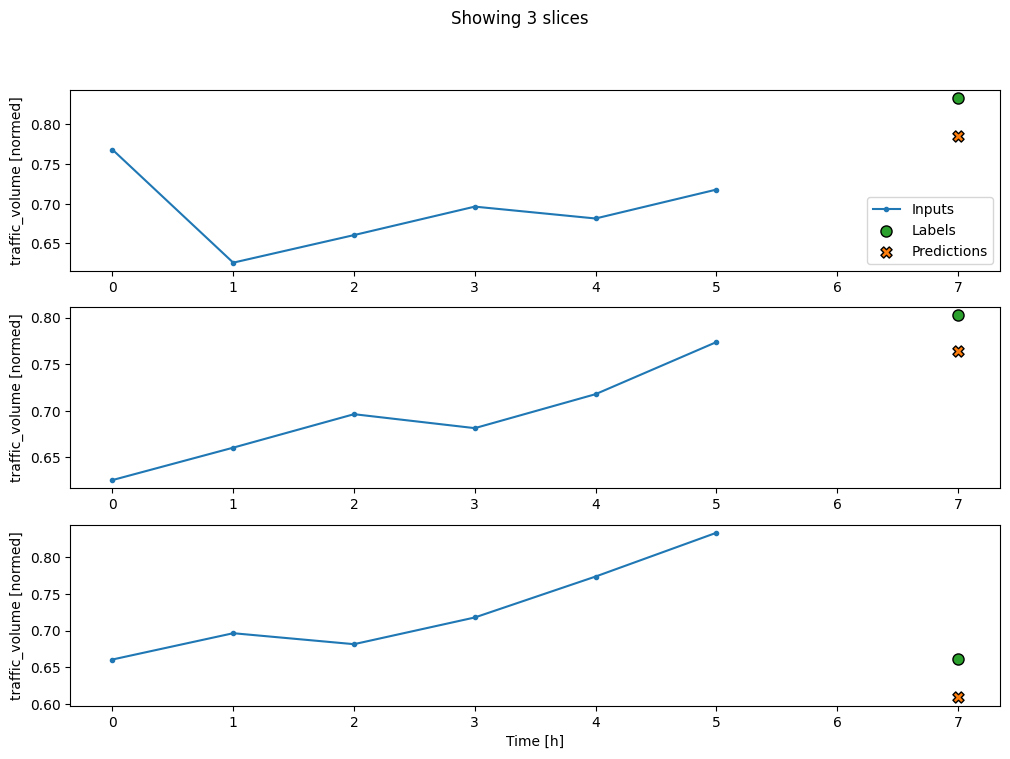

In [102]:
current_window.plot(dense_model)

#### CNN

A convolutional model predicts based on a fixed-width historical context, potentially outperforming the dense model by capturing patterns and trends over time.

TRAINING VS. VALIDATION


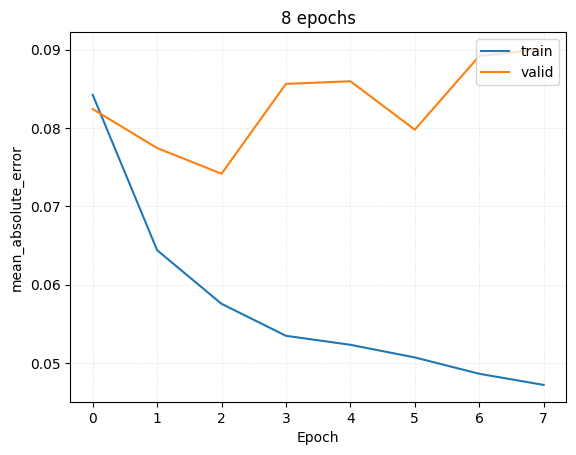



 VALIDATION SCORES: 

320/320 - 1s - 2ms/step - loss: 0.0120 - mean_absolute_error: 0.0742
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
PREDICTIONS EVALUATION:
Predictions: 10212
MAE:535.11 (0.0740)


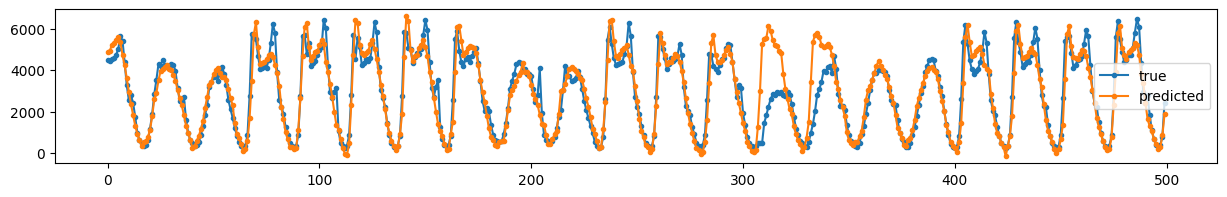

In [103]:
current_window = base_window

CONV_WIDTH =3
conv_model = tf.keras.Sequential([
    Lambda(lambda x: x[:, -CONV_WIDTH:, :]),
    Conv1D(256, activation='relu', kernel_size=(CONV_WIDTH)),
    Dense(512, activation='relu'),
    Dense(OUT_STEPS)
])

history = compile_and_fit(conv_model, current_window, model_label= 'CNN',
                          log_dict=my_log)

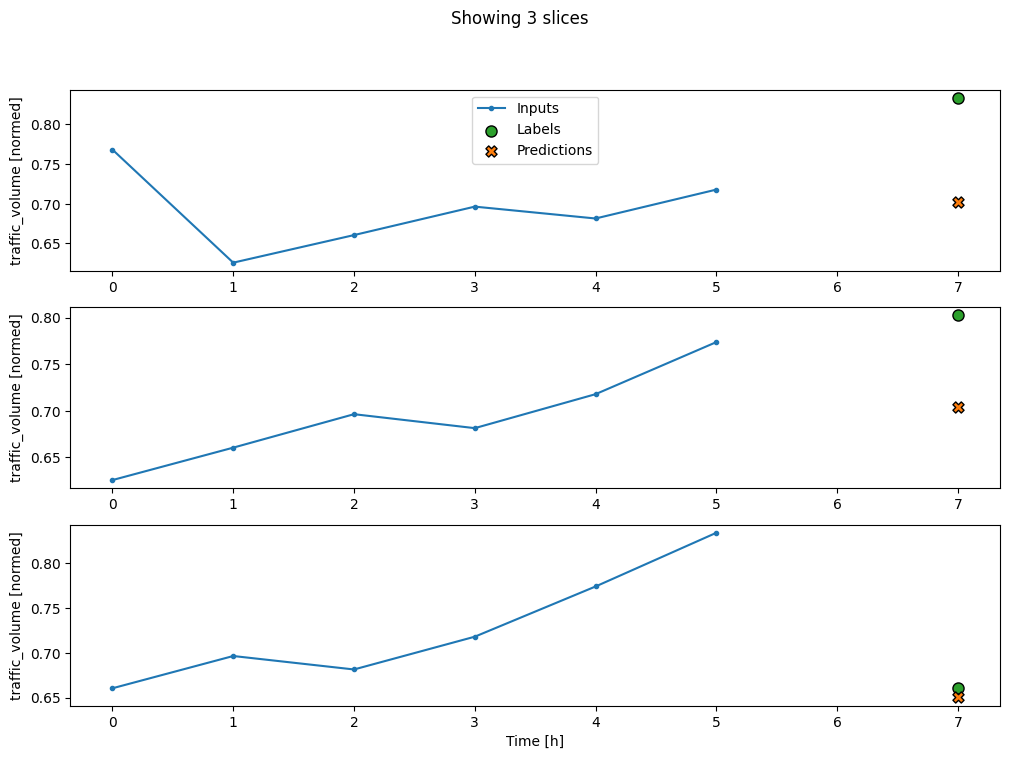

In [104]:
current_window.plot(conv_model)

#### RNN

TRAINING VS. VALIDATION


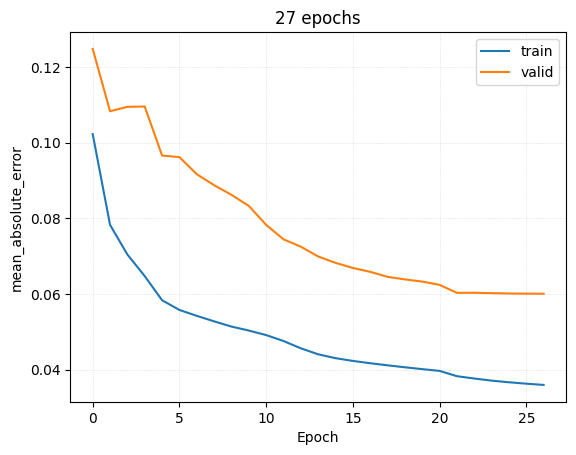



 VALIDATION SCORES: 

320/320 - 1s - 3ms/step - loss: 0.0070 - mean_absolute_error: 0.0603
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
PREDICTIONS EVALUATION:
Predictions: 10212
MAE:435.01 (0.0601)


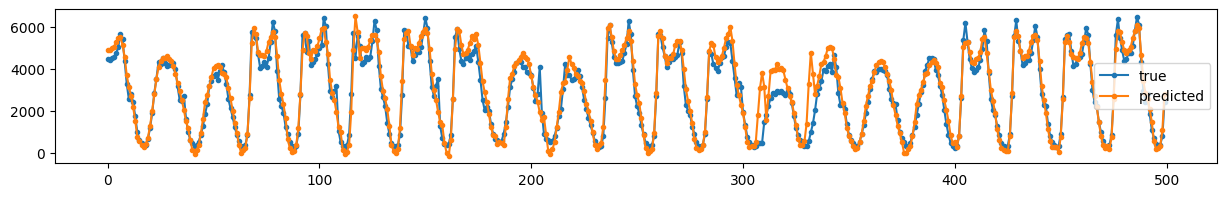

In [151]:
lstm_model = tf.keras.Sequential([
    LSTM(32, return_sequences=False),
    Dense(OUT_STEPS*33, kernel_initializer=tf.initializers.zeros()),
    Dense(OUT_STEPS),
    tf.keras.layers.Reshape([1, -1]),
])

history = compile_and_fit(lstm_model, current_window,
                          model_label='LSTM', log_dict=my_log)

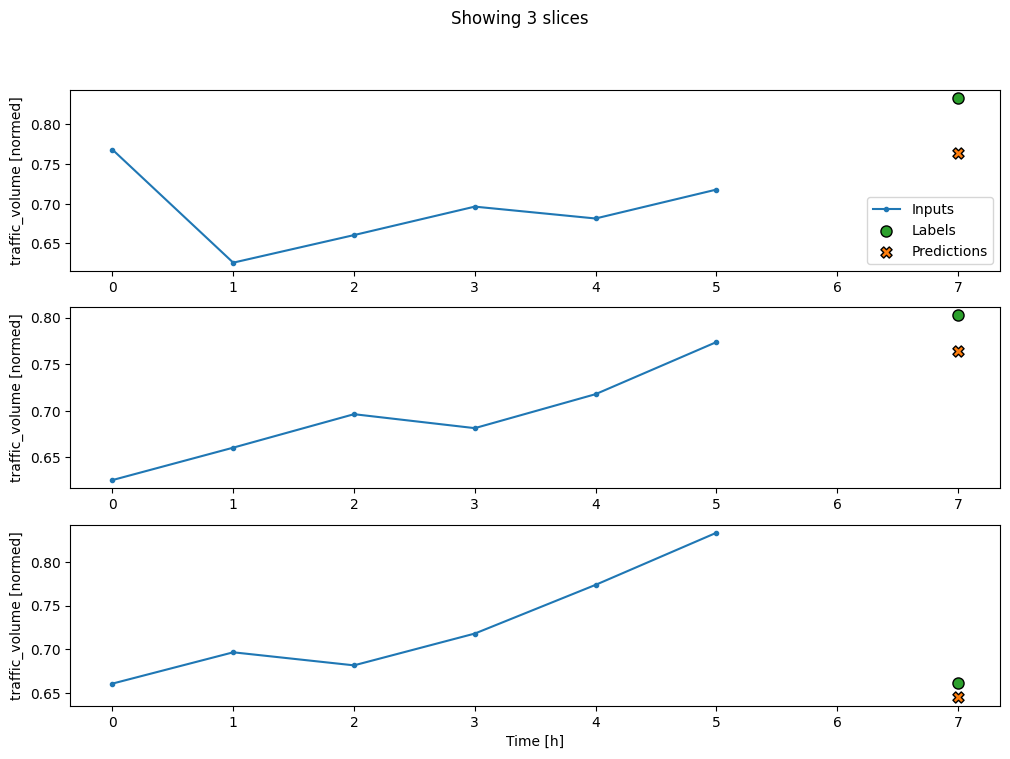

In [148]:
current_window.plot(lstm_model)

#### Model 2 with batch size = 64

In [149]:
base_window2 = WindowGenerator(input_width=INPUT_WIDTH,
                               label_width=OUT_STEPS,
                               shift=SHIFT, label_columns=['traffic_volume'],
                               batch_size=64)
base_window2

Total window size: 8
Input indices: [0 1 2 3 4 5]
Label indices: [7]
Label column name(s): ['traffic_volume']

TRAINING VS. VALIDATION


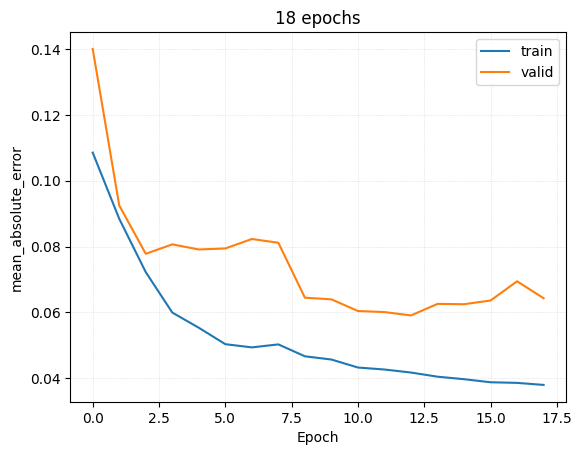



 VALIDATION SCORES: 

160/160 - 5s - 31ms/step - loss: 0.0073 - mean_absolute_error: 0.0591
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step
PREDICTIONS EVALUATION:
Predictions: 10212
MAE:426.20 (0.0589)


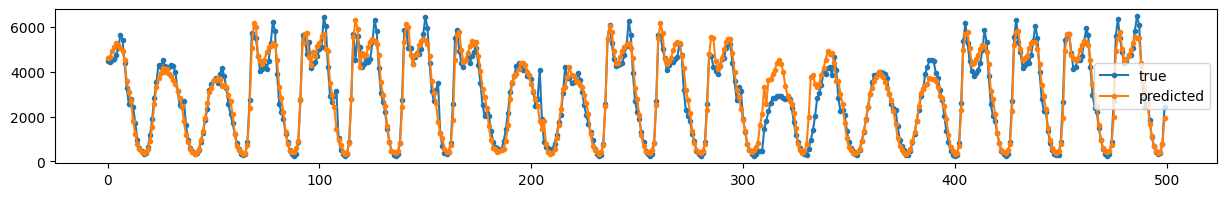

In [154]:
# LSTM with batch size=64
current_window = base_window2
lstm_model2 = tf.keras.Sequential([
    LSTM(512, return_sequences=True),
    LSTM(512, return_sequences=False),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(OUT_STEPS)
])
history = compile_and_fit(lstm_model2, current_window,
                          model_label='lstm_model2', log_dict=my_log,
                          )

TRAINING VS. VALIDATION


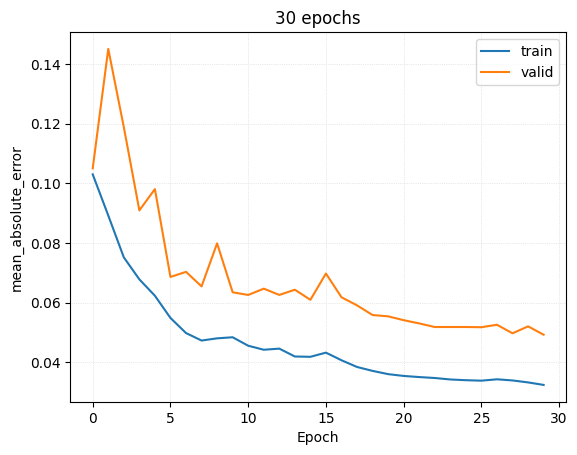



 VALIDATION SCORES: 

160/160 - 10s - 65ms/step - loss: 0.0055 - mean_absolute_error: 0.0492
160/160 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step
PREDICTIONS EVALUATION:
Predictions: 10212
MAE:355.22 (0.0491)


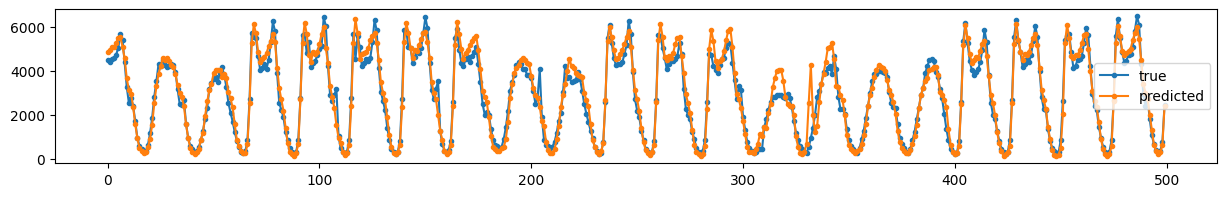

In [157]:
# Bidirectional LSTM with batch size = 64)
current_window = base_window2

forward_layer = LSTM(512, return_sequences=True)
backward_layer = LSTM(512, return_sequences=True, go_backwards=True)
 
bidirectional_lstm_model = tf.keras.Sequential([
    Bidirectional(forward_layer, backward_layer=backward_layer),
    Bidirectional(LSTM(512, return_sequences=False, stateful=False)),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(OUT_STEPS)
])

history = compile_and_fit(bidirectional_lstm_model, current_window,
                          model_label='lstm_model_bidirectional', log_dict=my_log,
                          )

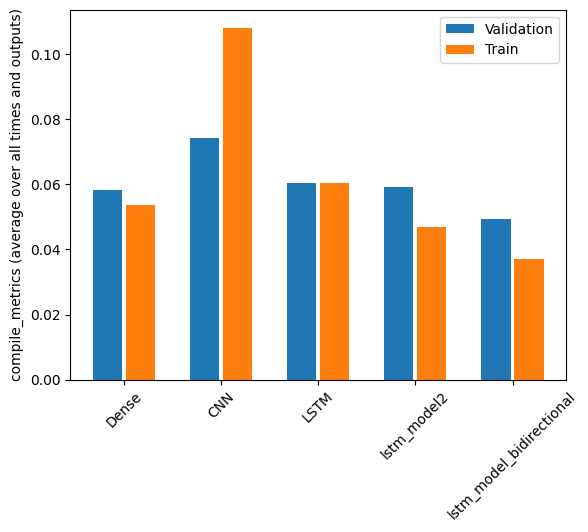

In [164]:

x = np.arange(len(multi_performance))
width = 0.3

metric_name = 'compile_metrics'
metric_index = bidirectional_lstm_model.metrics_names.index(metric_name)
val_mae = [v[metric_index] for v in multi_val_performance.values()]
test_mae = [v[metric_index] for v in multi_performance.values()]

plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Train')
plt.xticks(ticks=x, labels=multi_performance.keys(), rotation=45)
plt.ylabel(f'{metric_name} (average over all times and outputs)')
_ = plt.legend()

In [163]:
print(bidirectional_lstm_model.metrics_names)


['loss', 'compile_metrics']


In [172]:
base_window3 = WindowGenerator(input_width=INPUT_WIDTH,
                               label_width=OUT_STEPS,
                               test_df=scaled_test_df,
                               shift=SHIFT, label_columns=['traffic_volume'],
                               batch_size=64)
base_window3

Total window size: 8
Input indices: [0 1 2 3 4 5]
Label indices: [7]
Label column name(s): ['traffic_volume']

In [173]:
final_predictions = my_models['lstm_model_bidirectional'].predict(base_window3.test)
final_predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step


array([[0.728862  ],
       [0.7889291 ],
       [0.82529527],
       ...,
       [0.3670019 ],
       [0.27986372],
       [0.17651163]], dtype=float32)

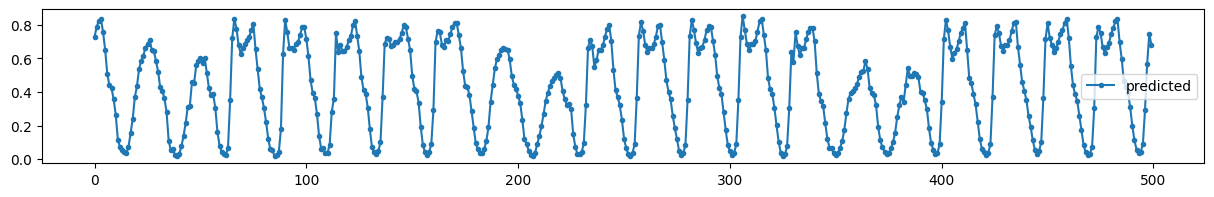

In [179]:
plt.subplots(figsize=(15,2))
plt.plot(final_predictions[:500], marker='.', label='predicted')
plt.legend()
plt.show()